In [27]:
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
import pickle

In [28]:
def mcl(N):
    """
    Loop-based Monte Carlo
    """
    sum = 0
    for i in range(N):
        sum += np.sin(np.random.random()*pi)
    return sum/N * pi

def mcv(N):
    """
    Vectorised Monte Carlo
    """
    p = np.random.random(N) * pi
    return np.sin(p).sum()/N * pi

In [29]:
%%timeit -n 10
mcl(10**4)

13.9 ms ± 1.03 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [30]:
%%timeit -n 10
mcv(10**4)

The slowest run took 4.05 times longer than the fastest. This could mean that an intermediate result is being cached.
293 µs ± 179 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


The vectorised implementation was around 70x faster than the looped version

In [31]:
14.4/0.212

67.9245283018868

In [32]:
def test(n, mc, pow):
    data = np.zeros(n)
    for i in range(n):
        data[i] = mc(10**pow)
    print(f"{data.mean():.5f}±{data.std()/np.sqrt(n):.5f}")
    print(f"{(data.std()/np.sqrt(n))/data.mean()}")

In [33]:
test(25, mcv, 5)

2.00059±0.00067
0.00033720576336550555


In [34]:
N = 10
V = (pi/8)**8

In [35]:
x0 = np.random.rand(8, 4)
x0.sum(axis=0)

array([3.4323424 , 4.3032851 , 4.67353653, 2.85956144])

In [36]:
def mc80(a, b, N, V):
    """
    Vectorised Monte Carlo for the octuple integral (initial attempt)
    """
    x0 = np.random.rand(8, N) * (b-a)
    x1 = np.random.random(N) * (b-a)
    x2 = np.random.random(N) * (b-a)
    x3 = np.random.random(N) * (b-a)
    x4 = np.random.random(N) * (b-a)
    x5 = np.random.random(N) * (b-a)
    x6 = np.random.random(N) * (b-a)
    x7 = np.random.random(N) * (b-a)
    
    ef1 = 10**6 * np.sin(x0+x1+x2+x3+x4+x5+x6+x7).sum()/N
    ef2 = ((10**6 * np.sin(x0+x1+x2+x3+x4+x5+x6+x7))**2).sum()/N

    estimate = V * ef1 
    sigma = V * ((ef2 - ef1**2)/N)**(0.5)
    
    return (estimate, sigma)

In [37]:
def mc8(a, b, N, V):
    """
    Fully vectorised Monte Carlo for the octuple integral (solution)
    """
    x = np.random.rand(8, N) * (b-a)
    
    sines = np.sin(x.sum(axis=0))
    ef1 = 10**6 * sines.sum()/N
    ef2 = ((10**6 * sines)**2).sum()/N

    estimate = V * ef1 
    sigma = V * ((ef2 - ef1**2)/N)**(0.5)
    
    return (estimate, sigma)

In [38]:
mc8(0, pi/8, 10**7, V)

(537.1843269253064, 0.011941652750730437)

In [39]:
# Calculating error from standard deviation of estimate from 25 independent 
# estimates
nt = 25
def mc8error(N):
    data = np.zeros(nt)
    sigmas = np.zeros(nt)
    for i in range(nt):
        data[i], sigmas[i] = mc8(0, pi/8, N, V)
    print(data.mean())
    return data.std(), sigmas.mean()

exp_errors = np.zeros(6)
the_errors = np.zeros(6)
for i in range(0, 6):
    exp_errors[i], the_errors[i] = mc8error(10**(i+1))


539.8782524846235
538.5195091928166
537.5177673657392
537.2706846693735
537.2115095134792
537.1700665846242


In [40]:
value, sigma = mc8(0, pi/8, 10**7, V)

In [41]:
sigma/value

2.2247075584040212e-05

In [1]:
Nvals = np.arange(1,7,1)
plt.plot(Nvals, np.log(exp_errors), label="experimental")
plt.plot(Nvals, np.log(the_errors), label="theoretical")
plt.title("Experimental vs theoretical error estimates for different N")
plt.xlabel("$log_{10}(N)$")
plt.ylabel("Error $\sigma$")
plt.legend();

NameError: name 'np' is not defined

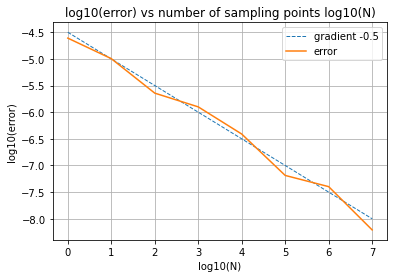

In [43]:
pickle_in = open("10e8error.pickle", "rb")
errors_p = pickle.load(pickle_in)
x_N = np.linspace(0,7,100)
plt.plot(x_N, -1/2*x_N-4.5, '--', lw=1, label="gradient -0.5")
plt.plot(np.arange(0,8,1), np.log10(errors_p), label="error")
plt.title("log10(error) vs number of sampling points log10(N)")
plt.xlabel("log10(N)")
plt.ylabel("log10(error)")
plt.grid()
plt.legend();

In [44]:
Nvals1 = 10**np.arange(0, 8, 1)

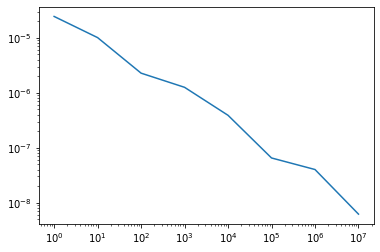

In [45]:
plt.loglog(Nvals1, errors_p)